In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/workspaces/Python-For-Data-Science/Database from Kaggle/dirty_cafe_sales.csv')


In [202]:
df.shape # the size of the index are 10000 followed by 8 columns 

(10000, 8)

In [203]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [204]:
df['Item'].hasnans # ok in our dataset there are several NaN values in our items columns

True

In [205]:
df[df['Item'].isnull()].count() # now we counted all values which are null in database.

Transaction ID      333
Item                  0
Quantity            330
Price Per Unit      326
Total Spent         329
Payment Method      251
Location            229
Transaction Date    327
dtype: int64

In [206]:
df[df['Item'].notnull()].count() 


Transaction ID      9667
Item                9667
Quantity            9532
Price Per Unit      9495
Total Spent         9498
Payment Method      7170
Location            6506
Transaction Date    9514
dtype: int64

In [207]:
df.shape # sorry woh experiment toh khoob mare but fr socha sab NaN uda deta hu kya hi hoga

(10000, 8)

In [208]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [209]:
bringmeback = {
    1.0 : "Cookie",
    2.0 : "Coffee",
    3.0 : "Cake",
    4.0 : "Smoothie",
    5.0 : "Salad"
}

In [210]:

df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(bringmeback))

df.shape # so this is our cleaned data

(10000, 8)

In [211]:
df.shape

(10000, 8)

In [212]:
# lets check that how many number of NaN and ERROR values in Quantity
df[df['Quantity']=='ERROR']

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
20,TXN_3522028,Smoothie,ERROR,4.0,20.0,Cash,In-store,2023-04-04
55,TXN_5522862,Cookie,ERROR,1.0,2.0,Credit Card,Takeaway,2023-03-19
117,TXN_2148617,Juice,ERROR,3.0,9.0,Digital Wallet,UNKNOWN,2023-01-10
177,TXN_1896955,Salad,ERROR,5.0,25.0,NaN,In-store,2023-09-23
178,TXN_5075974,Smoothie,ERROR,4.0,16.0,Digital Wallet,NaN,2023-04-11
...,...,...,...,...,...,...,...,...
9832,TXN_3325234,Tea,ERROR,1.5,1.5,ERROR,In-store,2023-08-26
9846,TXN_7621213,Coffee,ERROR,2.0,6.0,NaN,In-store,2023-03-07
9911,TXN_2464054,Coffee,ERROR,2.0,10.0,NaN,Takeaway,2023-08-18
9935,TXN_9778251,Tea,ERROR,1.5,6.0,NaN,Takeaway,2023-11-09


In [213]:
df['Quantity'] = df['Quantity'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Total Spent'] = df['Total Spent'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Price Per Unit'] = df['Price Per Unit'].replace(['ERROR', 'UNKNOWN'], np.nan)



df['Quantity'] = pd.to_numeric(df['Quantity'])
df['Total Spent'] = pd.to_numeric(df['Total Spent'])
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'])


df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])

df.head(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3.0,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5.0,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31


In [214]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
df['Total Spent'] = df['Total Spent'].fillna(df['Price Per Unit'] / df['Quantity'])


df.tail(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9980,TXN_6796890,Tea,4.0,1.5,6.0,UNKNOWN,NaN,2023-08-24
9981,TXN_4583012,ERROR,5.0,4.0,20.0,Digital Wallet,NaN,2023-02-27
9982,TXN_8567525,Cookie,2.0,1.0,2.0,NaN,Takeaway,2023-12-30
9983,TXN_9226047,Smoothie,3.0,4.0,12.0,Cash,NaN,UNKNOWN
9984,TXN_3142496,Smoothie,1.0,4.0,4.0,Cash,Takeaway,2023-07-27
9985,TXN_3297457,Cake,2.0,3.0,6.0,NaN,UNKNOWN,2023-01-03
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-store,2023-12-14
9987,TXN_1784478,Juice,5.0,3.0,15.0,Cash,NaN,2023-07-31
9988,TXN_9594133,Cake,5.0,3.0,0.6,ERROR,NaN,NaN
9989,TXN_1741685,Juice,5.0,3.0,15.0,Cash,NaN,2023-08-18


In [215]:
# now its time to set the payment method colum
# there are lots of NaN values and some values are UNKNOWN or ERROR 
# so I decided that i don't want to delete these NaN values so i m gonna replace them with cash 
# because cash  is the most common way of transaction

<Axes: >

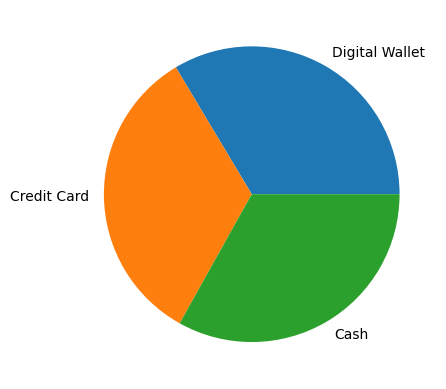

In [ ]:
# we are just want to see that is cash is really common :

a = df['Payment Method'].replace(['UNKNOWN','ERROR'], np.nan)
a.value_counts().plot(kind='pie')

In [221]:
def new(value):
    if pd.isna(value['Payment Method']):
       df['Payment Method'] = np.random.choice(value, size=len(df['Payment Method']))
       return df['Payment Method']

In [224]:
'''value = ['Cash', 'Credit Card', 'Digital Wallet']
df['Payment Method'] = df['Payment Method'].replace(['UNKNOWN','ERROR'], np.nan)
df['Payment Method'].apply(new, axis=1)


df.head(30)'''

"value = ['Cash', 'Credit Card', 'Digital Wallet']\ndf['Payment Method'] = df['Payment Method'].replace(['UNKNOWN','ERROR'], np.nan)\ndf['Payment Method'].apply(new, axis=1)\n\n\ndf.head(30)"